# v10 — Order Block: entry kecil (scalp) lawan arah saat ada Order Block lawan sinyal

**Latar belakang:** analisis trade_log_full.csv v06 menemukan Order Block (SMC) M5/H1 lawan arah
sinyal berkorelasi kuat dengan LOSS -- 57.8% dari semua LOSS v06 terjadi saat kondisi ini muncul,
padahal cuma 41% dari total trade. Kelompok trade dengan OB lawan arah rugi bersih -$2050 secara
agregat, sementara kelompok tanpa OB lawan arah untung +$4375 (dari total net v06 +$2325).

**Iterasi ide (riwayat singkat):**
1. Percobaan pertama: REVERSE PENUH (SL/TP sama besar dgn sinyal normal, 2x/4x ATR) -- hasil TEST
   out-of-sample nunjukkin tanda overfitting (win rate trade reverse turun dari 56.8% TRAIN ke
   51.2% TEST, hampir coin-flip; profit factor kalah dari SKIP). **Ditolak.**
2. Investigasi lanjutan: dicek apakah OB M5/H1 "didukung" struktur H4/D1 (level lebih besar) bisa
   mempertajam keputusan -- hasil grid sensitivity (lookback x tolerance) TIDAK konsisten, pola
   hilang begitu parameter diubah. **Overfitting juga, ditolak.**
3. Investigasi price path: dicek pergerakan candle-by-candle SEBELUM kena SL -- 77.5% trade LOSS
   ini SEMPAT bergerak searah dulu (avg ~3.9 poin, median ~26% dari jarak SL) sebelum berbalik.
   Ini beda dgn premis reverse penuh -- bukan "harga langsung salah arah total", tapi "ada jendela
   kecil untung searah, LALU berbalik lebih jauh".
4. **Ide v10 final (instruksi user):** BUKAN reverse penuh dgn TP/SL sebesar sinyal normal, tapi
   entry LAWAN arah (ikuti OB) dengan **TP/SL kecil** -- scalp jendela reversal itu, bukan trade
   besar. Grid search awal (686 kejadian, seluruh data) nemuin SL=1.0x/TP=1.5x ATR profit factor
   1.25, tapi SL yang TERLALU kecil (0.25x) malah rugi besar (kena whipsaw candle biasa).

**Yang divalidasi di notebook ini:**
- Grid search SL/TP kecil untuk trade reverse dilakukan HANYA di TRAIN (2025-01 s/d 2026-02),
  supaya parameter terpilih tidak "mengintip" TEST set
- TEST set (2026-03 s/d 2026-08, rezim harga tinggi -- kondisi live) dipakai HANYA untuk validasi
  independen dengan parameter yang SUDAH ditentukan dari TRAIN, tidak di-tuning ulang
- Dibandingkan lagi dengan SKIP (opsi paling konservatif) dan v06 baseline murni
- Sinyal normal (tanpa OB lawan arah) TETAP pakai SL=2.0x/TP=4.0x ATR seperti v06 -- v10 cuma
  menambah 1 jalur baru (entry kecil saat OB lawan arah), tidak mengubah strategi utama

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals import generate_signal

STRATEGY_NAME = "m5_scalping"
VERSION = "v10"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1, split train/test berbasis waktu (BUKAN random)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

BACKTEST_START = "2025-01-01"
TRAIN_END = "2026-03-01"  # 14 bulan pertama (2025-01 s/d 2026-02) = TRAIN
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)

print("M5 + konteks H1:", df_bt.shape, df_bt["datetime"].min(), "->", df_bt["datetime"].max())

M5 + konteks H1: (107336, 159) 2025-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 2. Generate sinyal (parameter v06, TIDAK diubah)

In [3]:
MIN_SIGNAL_SCORE = 9.0
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03
REQUIRE_H1_ALIGNMENT = True
SL_MULT = 2.0
TP_MULT = 4.0
MAX_HOLD_CANDLES = 12

directions = np.empty(len(df_bt), dtype=object)
scores = np.zeros(len(df_bt))
for pos, (_, row) in enumerate(df_bt.iterrows()):
    result = generate_signal(row, MIN_SIGNAL_SCORE, ADX_MIN, ATR_MIN_PCT, REQUIRE_H1_ALIGNMENT)
    directions[pos] = result.direction
    scores[pos] = result.final_score

df_bt["signal_direction"] = directions
df_bt["signal_score"] = scores

print("Baris backtest:", len(df_bt))
df_bt["signal_direction"].value_counts()

Baris backtest: 107336


signal_direction
WAIT    103287
BUY       2498
SELL      1551
Name: count, dtype: int64

## 3. Backtest engine — sinyal normal (SL=2x/TP=4x ATR) + entry kecil saat OB lawan arah

`small_tp_on_ob=True`: kalau sinyal asli BUY & ada `ob_bear`/`h1_ob_bear` aktif -> BUKAN eksekusi
BUY (skip sinyal asli), tapi entry SELL kecil dengan `sl_mult_small`/`tp_mult_small` terpisah
(jauh lebih kecil dari 2x/4x sinyal normal) -- scalp jendela reversal singkat, bukan trade besar
melawan trend utama.

In [4]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30
MAX_HOLD_SMALL_CANDLES = 6  # entry kecil di-exit lebih cepat (30 menit), bukan 12 candle spt sinyal normal

RAW_INDICATOR_COLUMNS = [c for c in df_bt.columns if c not in ("timestamp", "datetime")]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def has_opposing_ob(row: pd.Series, direction: str) -> bool:
    if direction == "BUY":
        return bool(row["ob_bear"] > 0 or row["h1_ob_bear"] > 0)
    else:
        return bool(row["ob_bull"] > 0 or row["h1_ob_bull"] > 0)


def run_backtest(
    df_signals: pd.DataFrame,
    sl_mult: float, tp_mult: float, max_hold_candles: int,
    mode: str,  # "baseline" | "skip" | "small_reverse"
    sl_mult_small: float = 1.0, tp_mult_small: float = 1.5,
    save_full_log: bool = False,
) -> tuple[pd.DataFrame, list[float]]:
    """mode="baseline": ikuti sinyal asli selalu (v06 murni, abaikan OB).
    mode="skip": skip trade sama sekali kalau ada OB lawan arah.
    mode="small_reverse": kalau ada OB lawan arah, entry LAWAN arah dgn sl_mult_small/tp_mult_small
    & max_hold lebih pendek -- kalau tidak ada OB lawan arah, tetap ikuti sinyal asli spt biasa.
    """
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        original_direction = row["signal_direction"]

        if original_direction == "WAIT":
            i += 1
            continue

        opposing = has_opposing_ob(row, original_direction)

        direction = original_direction
        is_small_reverse = False
        cur_sl_mult, cur_tp_mult, cur_max_hold = sl_mult, tp_mult, max_hold_candles

        if opposing:
            if mode == "skip":
                i += 1
                continue
            if mode == "small_reverse":
                direction = "SELL" if original_direction == "BUY" else "BUY"
                is_small_reverse = True
                cur_sl_mult, cur_tp_mult, cur_max_hold = sl_mult_small, tp_mult_small, MAX_HOLD_SMALL_CANDLES
            # mode == "baseline": biarkan direction = original_direction (abaikan OB)

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = cur_sl_mult * atr
        tp_points = cur_tp_mult * atr

        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price: float | None = None
        exit_time = None
        exit_reason = None
        exit_idx = min(i + cur_max_hold, n - 1)  # fallback TIMEOUT candle, selalu terdefinisi

        window_end = min(i + 1 + cur_max_hold, n)
        for candle_idx in range(i + 1, window_end):
            candle = df_signals.iloc[candle_idx]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price

            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                exit_idx = candle_idx
                break

        if exit_price is None:
            last_candle = df_signals.iloc[exit_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"

        next_i = exit_idx + 1
        hold_candles = exit_idx - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time, "exit_time": exit_time,
            "original_direction": original_direction, "direction": direction,
            "is_small_reverse": is_small_reverse,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price, "sl_price": sl_price,
            "atr_at_entry": atr, "sl_points": sl_points, "tp_points": tp_points,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "signal_score": row["signal_score"], "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}
    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }

## 4. TRAIN set (2025-01 s/d 2026-02): grid search SL/TP kecil utk entry reverse

Parameter dipilih HANYA dari TRAIN -- TEST set di section 5 sama sekali tidak dilihat di sini.

In [5]:
df_train = df_bt[df_bt["datetime"] < TRAIN_END].reset_index(drop=True)
df_test = df_bt[df_bt["datetime"] >= TRAIN_END].reset_index(drop=True)
print(f"TRAIN: {len(df_train)} baris, {df_train['datetime'].min()} -> {df_train['datetime'].max()}")
print(f"TEST : {len(df_test)} baris, {df_test['datetime'].min()} -> {df_test['datetime'].max()}")

trades_train_baseline, _ = run_backtest(df_train, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, mode="baseline")
metrics_train_baseline = evaluate(trades_train_baseline, INITIAL_EQUITY)
print()
print("=== TRAIN: v06 baseline (abaikan OB sepenuhnya) ===")
for k, v in metrics_train_baseline.items():
    print(f"  {k}: {v}")

sl_small_candidates = [0.5, 0.75, 1.0, 1.25]
tp_small_candidates = [0.5, 0.75, 1.0, 1.5, 2.0]

grid_results = []
for sl_s in sl_small_candidates:
    for tp_s in tp_small_candidates:
        trades, _ = run_backtest(
            df_train, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, mode="small_reverse",
            sl_mult_small=sl_s, tp_mult_small=tp_s,
        )
        metrics = evaluate(trades, INITIAL_EQUITY)
        reversed_trades = trades[trades["is_small_reverse"]]
        metrics.update({
            "sl_mult_small": sl_s, "tp_mult_small": tp_s, "rr": round(tp_s / sl_s, 2),
            "n_small_reverse": len(reversed_trades),
            "small_reverse_win_rate": round((reversed_trades["pnl"] > 0).mean() * 100, 1) if len(reversed_trades) else None,
            "small_reverse_net_pnl": round(reversed_trades["pnl"].sum(), 2) if len(reversed_trades) else 0,
        })
        grid_results.append(metrics)

grid_df = pd.DataFrame(grid_results).sort_values("final_equity", ascending=False)
print()
print("=== Grid search TRAIN: top 10 kombinasi sl_mult_small x tp_mult_small ===")
grid_df.head(10)

TRAIN: 77226 baris, 2025-01-01 23:00:00+00:00 -> 2026-02-27 21:55:00+00:00
TEST : 30110 baris, 2026-03-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00



=== TRAIN: v06 baseline (abaikan OB sepenuhnya) ===
  total_trades: 1172
  win_rate_pct: 50.17
  profit_factor: 1.31
  net_pnl: 1139.58
  final_equity: 1239.58
  max_drawdown_pct: -28.43
  min_equity: 88.15
  trading_days: 278
  avg_daily_pnl: 4.1
  avg_trades_per_day: 4.22



=== Grid search TRAIN: top 10 kombinasi sl_mult_small x tp_mult_small ===


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,sl_mult_small,tp_mult_small,rr,n_small_reverse,small_reverse_win_rate,small_reverse_net_pnl
4,1366,47.66,1.75,7118.57,7218.57,-15.94,89.80,279,25.51,4.90,0.50,2.00,4.00,612,29.1,2421.05
9,1328,52.48,1.82,6450.13,6550.13,-18.13,91.30,279,23.12,4.76,0.75,2.00,2.67,582,39.0,1927.22
14,1298,56.09,1.90,6025.34,6125.34,-12.51,90.12,279,21.60,4.65,1.00,2.00,2.00,558,46.6,1573.58
19,1282,58.50,1.97,5819.63,5919.63,-13.66,88.94,279,20.86,4.59,1.25,2.00,1.60,543,51.9,1264.49
18,1291,59.02,1.95,5177.71,5277.71,-13.66,88.94,279,18.56,4.63,1.25,1.50,1.20,549,53.6,942.93
3,1374,48.03,1.68,5166.91,5266.91,-15.18,89.80,279,18.52,4.92,0.50,1.50,3.00,618,30.3,1294.86
13,1308,56.42,1.85,4825.20,4925.20,-12.51,90.12,279,17.29,4.69,1.00,1.50,1.50,565,47.8,898.01
8,1339,52.88,1.76,4557.13,4657.13,-19.29,91.30,279,16.33,4.80,0.75,1.50,2.00,590,40.3,1057.59
17,1303,61.93,2.01,4553.93,4653.93,-13.63,89.18,279,16.32,4.67,1.25,1.00,0.80,557,60.3,838.31
16,1314,64.16,2.05,4147.40,4247.40,-13.73,88.39,279,14.87,4.71,1.25,0.75,0.60,562,65.7,661.17


## 5. Pilih parameter terbaik dari TRAIN, lalu validasi MURNI di TEST (2026-03 s/d 2026-08)

Parameter (`SL_MULT_SMALL`, `TP_MULT_SMALL`) di bawah sudah FIXED dari hasil grid search TRAIN --
TIDAK di-tuning ulang pakai TEST. Ini validasi out-of-sample yang jujur.

In [6]:
best_small = grid_df.iloc[0]
SL_MULT_SMALL = float(best_small["sl_mult_small"])
TP_MULT_SMALL = float(best_small["tp_mult_small"])
print(f"Parameter terpilih dari TRAIN: SL_MULT_SMALL={SL_MULT_SMALL}, TP_MULT_SMALL={TP_MULT_SMALL}")

trades_test_baseline, curve_test_baseline = run_backtest(df_test, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, mode="baseline")
trades_test_small, curve_test_small = run_backtest(
    df_test, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, mode="small_reverse",
    sl_mult_small=SL_MULT_SMALL, tp_mult_small=TP_MULT_SMALL, save_full_log=True,
)

metrics_test_baseline = evaluate(trades_test_baseline, INITIAL_EQUITY)
metrics_test_small = evaluate(trades_test_small, INITIAL_EQUITY)

comparison_test = pd.DataFrame({
    "TEST — v06 baseline (abaikan OB)": metrics_test_baseline,
    "TEST — v10 (small reverse saat OB)": metrics_test_small,
})
print()
print("=== Perbandingan TEST set (2026-03 s/d 2026-08, out-of-sample) ===")
comparison_test

Parameter terpilih dari TRAIN: SL_MULT_SMALL=0.5, TP_MULT_SMALL=2.0



=== Perbandingan TEST set (2026-03 s/d 2026-08, out-of-sample) ===


,TEST — v06 baseline (abaikan OB),TEST — v10 (small reverse saat OB)
total_trades,492.00,598.00
win_rate_pct,50.20,45.32
profit_factor,1.37,1.51
net_pnl,917.29,1619.71
final_equity,1017.29,1719.71
max_drawdown_pct,-98.92,-47.31
min_equity,1.58,54.61
trading_days,117.00,117.00
avg_daily_pnl,7.84,13.84
avg_trades_per_day,4.21,5.11


In [7]:
small_reverse_test = trades_test_small[trades_test_small["is_small_reverse"]]
non_reverse_test = trades_test_small[~trades_test_small["is_small_reverse"]]

print(f"TEST set — total trade v10: {len(trades_test_small)}")
print(f"Jumlah entry small-reverse (saat ada OB lawan arah): {len(small_reverse_test)}")
print()
print("=== Performa KHUSUS entry small-reverse (TEST, out-of-sample) ===")
if len(small_reverse_test) > 0:
    print(f"  n = {len(small_reverse_test)}")
    print(f"  win_rate = {(small_reverse_test['pnl']>0).mean()*100:.1f}%")
    print(f"  net_pnl = {small_reverse_test['pnl'].sum():.2f}")
    print(f"  avg_pnl_per_trade = {small_reverse_test['pnl'].mean():.3f}")
else:
    print("  Tidak ada entry small-reverse di TEST set.")
print()
print("=== Performa trade normal (tanpa OB lawan arah, sinyal asli spt v06) ===")
print(f"  n = {len(non_reverse_test)}")
print(f"  win_rate = {(non_reverse_test['pnl']>0).mean()*100:.1f}%")
print(f"  net_pnl = {non_reverse_test['pnl'].sum():.2f}")

# konsistensi TRAIN vs TEST
train_small_reverse = trades_train_small_final = None
best_train_row = grid_df.iloc[0]
print()
print("=== Konsistensi TRAIN vs TEST (win rate small-reverse) ===")
print(f"  TRAIN: {best_train_row['small_reverse_win_rate']}%")
print(f"  TEST : {(small_reverse_test['pnl']>0).mean()*100:.1f}%" if len(small_reverse_test) else "  TEST: n/a")

TEST set — total trade v10: 598
Jumlah entry small-reverse (saat ada OB lawan arah): 299

=== Performa KHUSUS entry small-reverse (TEST, out-of-sample) ===
  n = 299
  win_rate = 27.8%
  net_pnl = -130.60
  avg_pnl_per_trade = -0.437

=== Performa trade normal (tanpa OB lawan arah, sinyal asli spt v06) ===
  n = 299
  win_rate = 62.9%
  net_pnl = 1750.31

=== Konsistensi TRAIN vs TEST (win rate small-reverse) ===
  TRAIN: 29.1%
  TEST : 27.8%


## 6. Cross-check: baseline vs SKIP vs SMALL-REVERSE, di TEST set yang sama

Ini penting -- membuktikan small-reverse lebih baik dari sekadar SKIP, bukan cuma lebih baik dari
"abaikan OB". Kalau SKIP ternyata sama baik/lebih baik, mendingan pakai SKIP (lebih konservatif,
gak buka posisi tambahan sama sekali di kondisi yang levelnya ambigu).

In [8]:
trades_test_skip, curve_test_skip = run_backtest(df_test, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, mode="skip")
metrics_test_skip = evaluate(trades_test_skip, INITIAL_EQUITY)

three_way = pd.DataFrame({
    "v06 baseline (abaikan OB)": metrics_test_baseline,
    "SKIP saat ada OB lawan arah": metrics_test_skip,
    "SMALL-REVERSE saat ada OB lawan arah (v10)": metrics_test_small,
})
print("=== TEST set (2026-03 s/d 2026-08): baseline vs SKIP vs SMALL-REVERSE ===")
three_way

=== TEST set (2026-03 s/d 2026-08): baseline vs SKIP vs SMALL-REVERSE ===


,v06 baseline (abaikan OB),SKIP saat ada OB lawan arah,SMALL-REVERSE saat ada OB lawan arah (v10)
total_trades,492.00,315.00,598.00
win_rate_pct,50.20,60.95,45.32
profit_factor,1.37,2.32,1.51
net_pnl,917.29,1615.83,1619.71
final_equity,1017.29,1715.83,1719.71
max_drawdown_pct,-98.92,-53.93,-47.31
min_equity,1.58,46.07,54.61
trading_days,117.00,99.00,117.00
avg_daily_pnl,7.84,16.32,13.84
avg_trades_per_day,4.21,3.18,5.11


## 7. Equity curve — TEST set, ketiga varian

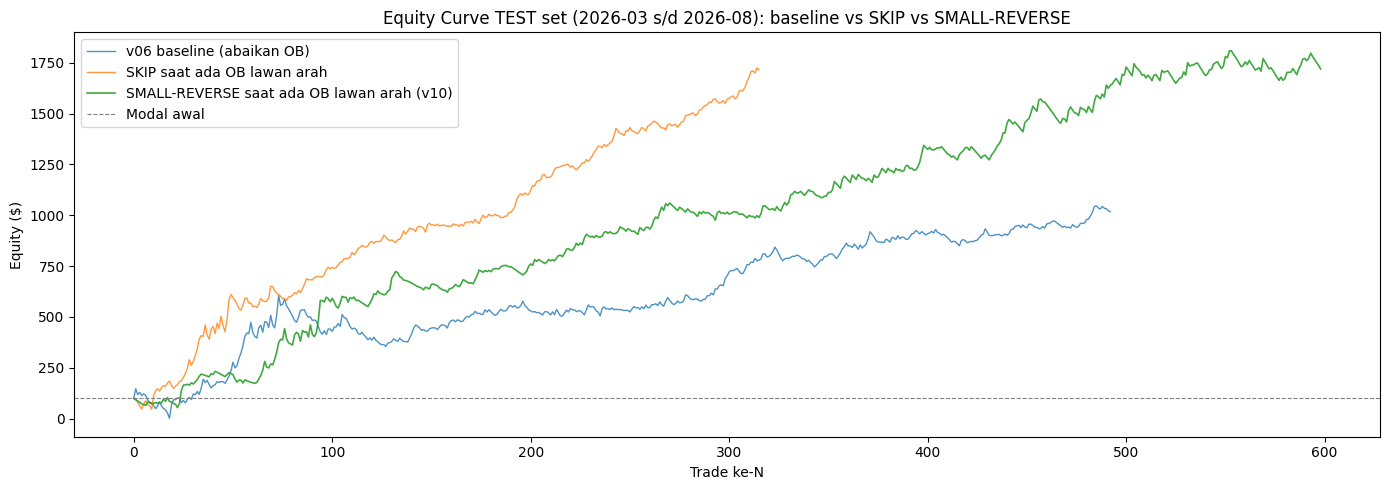

In [9]:
fig, ax = plt.subplots()
ax.plot(curve_test_baseline, label="v06 baseline (abaikan OB)", alpha=0.8, linewidth=1.0)
ax.plot(curve_test_skip, label="SKIP saat ada OB lawan arah", alpha=0.8, linewidth=1.0)
ax.plot(curve_test_small, label="SMALL-REVERSE saat ada OB lawan arah (v10)", alpha=0.9, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title("Equity Curve TEST set (2026-03 s/d 2026-08): baseline vs SKIP vs SMALL-REVERSE")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve_test_comparison.png", dpi=120)
plt.show()

## 8. Kesimpulan & keputusan

Kriteria buat pertimbangkan v10 (small-reverse) layak dipakai, BUKAN overfitting:
1. Win rate entry small-reverse di TEST (out-of-sample) harus jelas > 50%, DAN tidak jauh
   merosot dari TRAIN (indikasi overfitting kalau merosot besar, spt kejadian di reverse-penuh
   sebelumnya: 56.8% TRAIN -> 51.2% TEST)
2. SMALL-REVERSE harus lebih baik dari SKIP di TEST -- kalau SKIP setara/lebih baik, gak worth
   risiko tambahan buka posisi di kondisi yang levelnya ambigu
3. Kontribusi net_pnl dari small-reverse harus positif & bukan cuma didorong 1-2 outlier trade

In [10]:
print("=== Checklist keputusan ===")
print()

sr_win_rate_test = (small_reverse_test["pnl"] > 0).mean() * 100 if len(small_reverse_test) else None
sr_win_rate_train = best_train_row["small_reverse_win_rate"]
if sr_win_rate_test is not None:
    print(f"1. Win rate small-reverse: TRAIN={sr_win_rate_train}%, TEST={sr_win_rate_test:.1f}%")
else:
    print("1. Tidak ada trade di TEST")
degradation = (sr_win_rate_train - sr_win_rate_test) if sr_win_rate_test is not None else None
if degradation is not None:
    print(f"   Selisih TRAIN-TEST: {degradation:.1f} poin persen")
lolos = (sr_win_rate_test or 0) > 50 and (degradation or 99) < 10
print(f"   -> {'LOLOS' if lolos else 'PERLU HATI-HATI / TIDAK LOLOS'}")
print()

small_vs_skip = metrics_test_small["final_equity"] - metrics_test_skip["final_equity"]
print(f"2. SMALL-REVERSE final_equity ({metrics_test_small['final_equity']}) vs "
      f"SKIP final_equity ({metrics_test_skip['final_equity']}): selisih = {small_vs_skip:.2f}")
print(f"   -> {'SMALL-REVERSE lebih baik' if small_vs_skip > 0 else 'SKIP lebih baik atau setara'}")
print()

sr_net_pnl = small_reverse_test["pnl"].sum() if len(small_reverse_test) else 0
sr_median_pnl = small_reverse_test["pnl"].median() if len(small_reverse_test) else 0
print(f"3. Net PnL dari small-reverse di TEST: {sr_net_pnl:.2f} (median per trade: {sr_median_pnl:.3f})")
if len(small_reverse_test):
    print(f"   Jumlah trade: {len(small_reverse_test)} -- kontribusi per trade avg: {sr_net_pnl/len(small_reverse_test):.3f}")

=== Checklist keputusan ===

1. Win rate small-reverse: TRAIN=29.1%, TEST=27.8%
   Selisih TRAIN-TEST: 1.3 poin persen
   -> PERLU HATI-HATI / TIDAK LOLOS

2. SMALL-REVERSE final_equity (1719.71) vs SKIP final_equity (1715.83): selisih = 3.88
   -> SMALL-REVERSE lebih baik

3. Net PnL dari small-reverse di TEST: -130.60 (median per trade: -6.174)
   Jumlah trade: 299 -- kontribusi per trade avg: -0.437


## 9. Simpan hasil

In [11]:
trades_test_small.to_csv(PROCESSED_OUT_DIR / "trade_log_test_v10.csv", index=False)
grid_df.to_csv(EXPORT_DIR / "grid_search_train_small_tp_sl.csv", index=False)
three_way.to_csv(EXPORT_DIR / "comparison_baseline_skip_smallreverse.csv")

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write("Backtest v10 -- Order Block: entry kecil (scalp) lawan arah saat ada OB lawan sinyal\n\n")
    f.write(f"Parameter terpilih dari TRAIN grid search: SL_MULT_SMALL={SL_MULT_SMALL}, "
            f"TP_MULT_SMALL={TP_MULT_SMALL}, MAX_HOLD_SMALL_CANDLES={MAX_HOLD_SMALL_CANDLES}\n\n")
    f.write("=== TRAIN (2025-01 s/d 2026-02) ===\n")
    f.write("v06 baseline:\n")
    for k, v in metrics_train_baseline.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"Best small-reverse (sl={SL_MULT_SMALL}, tp={TP_MULT_SMALL}):\n")
    for k, v in best_small.items():
        f.write(f"  {k}: {v}\n")
    f.write("\n=== TEST (2026-03 s/d 2026-08, out-of-sample) ===\n")
    f.write("v06 baseline:\n")
    for k, v in metrics_test_baseline.items():
        f.write(f"  {k}: {v}\n")
    f.write("SKIP saat ada OB lawan arah:\n")
    for k, v in metrics_test_skip.items():
        f.write(f"  {k}: {v}\n")
    f.write("SMALL-REVERSE saat ada OB lawan arah (v10):\n")
    for k, v in metrics_test_small.items():
        f.write(f"  {k}: {v}\n")
    if sr_win_rate_test is not None:
        f.write(f"  win_rate small-reverse: {sr_win_rate_test}\n")
    f.write(f"  net_pnl small-reverse: {sr_net_pnl}\n")

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v10
 - comparison_baseline_skip_reverse.csv
 - comparison_baseline_skip_smallreverse.csv
 - equity_curve_test_comparison.png
 - grid_search_train_small_tp_sl.csv
 - metrics.txt
